[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlos-argueta/factor-graphs-from-scratch/blob/main/modules/03-factor-graphs-from-scratch/lesson.ipynb)

# Module 3 — Factor graphs from scratch (Euclidean)

> **Goal.** Build the small engine that everything after this runs on. A **factor graph** is just two kinds of object — **variables** (the unknowns) and **factors** (the local measurements that constrain them) — plus the machinery to *assemble* them into one big least-squares problem and hand it to the Gauss–Newton / Levenberg–Marquardt solver we wrote in M1. By the end we have a working **batch optimiser** and use it to redo 1D and 2D localisation.

This is where the three previous modules snap together:

$$\boxed{\text{M0 (one 2-factor solve)} \;+\; \text{M1 (GN/LM)} \;+\; \text{M2 (sparse } \Lambda\text{)} \;=\; \text{a factor-graph engine}}$$

M0 showed a Kalman update *is* a two-factor solve. M1 built the nonlinear solver. M2 showed the information matrix $\Lambda$ *is* the graph. Here we write the object that holds the graph, builds $\Lambda$ (implicitly, through $J$), and solves — so that from M4 on we just *declare* variables and factors and press go.

In [1]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `factorgraph`) importable.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + factorgraph)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "factorgraph").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

## 1 · From a residual function to a graph

In M1 the solver signature was `gauss_newton(residual_fn, x0)`, where you hand it **one** function returning the whole stacked residual $r(x)$ and its Jacobian $J=\partial r/\partial x$. That is fine for fitting a curve: one model, one parameter vector, one $r$.

But a real estimation problem is not one big residual — it is *many small ones*. A robot trajectory has dozens of poses (the variables) and, touching them, a scatter of local measurements: a GPS fix on pose 12, odometry between poses 7 and 8, a range to a beacon from pose 3. Each measurement constrains only **a few** variables. Hand-writing the giant $J$ for all of them is tedious and error-prone — and, worse, it throws away the structure M2 made so much of: most of $J$ (and of $\Lambda=J^\top J$) is **zero**.

A **factor graph** is the data structure that fixes both problems. It is *bipartite* — its nodes come in two kinds, and every edge joins one kind to the other (a full definition is in **Appendix E**):

- **variables** — the unknowns we solve for (a pose, a point, a calibration). Drawn as circles.
- **factors** — one per piece of information (a prior, a measurement), each a little residual  touching only the variables it mentions. Drawn as squares.

You *declare* the factors; the graph *assembles* $r$ and $J$ for you, writing each factor's contribution into exactly the rows and columns it touches and leaving the rest zero. Solving the graph means the same thing it always did — find the variable values that minimise the total whitened squared residual — but now the bookkeeping is automatic and the sparsity is free.

We build three things: **(§2)** a way to lay variables out into a state vector, **(§3)** factors that each emit a local residual and Jacobian, and **(§4)** the graph that stacks them and calls the M1 solver **(§5)**. Then we drive it: 1D **(§5)** and 2D **(§6)** localisation.

> We build the classes **inline** here so you watch the engine come together. Once the lesson is settled they move into `factorgraph/graph.py` next to `factorgraph/nls.py`, and M4+ simply `import` them.

In [2]:
import matplotlib.pyplot as plt

# palette (light surface) + recessive chrome  — shared with M0/M1/M2
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def _style(ax, title):
    ax.set_title(title, color=INK, fontsize=11, pad=8)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)

## 2 · Variables, values, and the ordering

A variable is identified by a **key** — anything hashable. We will use integers `0,1,2,…` for a chain of poses and strings like `"x"` for one-off variables. The current estimate for every variable is a plain dict, key $\to$ numpy vector; call it **`values`** (GTSAM calls the same object `Values`, which is deliberate — M6 maps this across).

To *solve*, though, the solver wants a single flat vector $x$. So we need an **ordering**: a rule that assigns each key a contiguous slice of $x$ — its block of **columns** in $J$. A 2D pose of dimension 2 takes two entries; stack them all and you have $x\in\mathbb R^n$.

The ordering is the only bridge between the friendly dict-of-vectors view and the flat linear-algebra view. `pack` folds a `values` dict into $x$; `unpack` does the reverse. (The *order* you choose turns out to matter a lot for sparsity — that is M2's fill-in and a preview of M5 — but any consistent order solves the same problem.)

In [3]:
class Ordering:
    """Assign each variable key a contiguous slice of the stacked state vector x."""
    def __init__(self, dims):                     # dims: {key: dimension}
        self.slices, i = {}, 0
        for k, d in dims.items():
            self.slices[k] = slice(i, i + d)
            i += d
        self.n = i                                # total state dimension
    def pack(self, values):                       # {key: vec}  ->  x  (n,)
        x = np.zeros(self.n)
        for k, s in self.slices.items():
            x[s] = np.atleast_1d(values[k])
        return x
    def unpack(self, x):                          # x  ->  {key: vec}
        return {k: x[s].copy() for k, s in self.slices.items()}

# demo: two 2D variables -> a length-4 state vector
ordering = Ordering({"a": 2, "b": 2})
x = ordering.pack({"a": [1.0, 2.0], "b": [3.0, 4.0]})
print("slices:", {k: (s.start, s.stop) for k, s in ordering.slices.items()})
print("packed x:", x, " ->  unpacked:", ordering.unpack(x))

slices: {'a': (0, 2), 'b': (2, 4)}
packed x: [1. 2. 3. 4.]  ->  unpacked: {'a': array([1., 2.]), 'b': array([3., 4.])}


## 3 · Factors: a local residual with a noise model

A **factor** is one piece of information. It knows the **keys** it touches and, given the current `values`, it can **linearise**: return its residual $r_f$ and the Jacobian block $\partial r_f/\partial x_k$ for each key $k$ it mentions. That is all the graph needs.

### Whitening: from a covariance to plain least squares

A measurement does not come bare — it comes with a covariance $\Sigma$ saying how much to trust it. Its contribution to the cost is the **Mahalanobis** norm $r^\top\Sigma^{-1}r$, not the plain $r^\top r$ that M1's solver minimises. We reconcile the two by **whitening**: find a matrix $W$ with $W^\top W=\Sigma^{-1}$ and pre-multiply, because

$$\lVert W r\rVert^2 = r^\top W^\top W\, r = r^\top \Sigma^{-1} r.$$

So every factor stores $W$ and returns the **whitened** residual $Wr$ and Jacobian $WJ$; after that the solver just minimises a sum of squares and the covariances are baked in. For a diagonal noise model (independent per-component standard deviations $\sigma$) this is simply $W=\operatorname{diag}(1/\sigma)$ — dividing each row by its $\sigma$. (Full $\Sigma$ via a Cholesky factor is **Appendix A**.) This is the exact same *square-root* trick M1 used to fold in robust weights — there on the kernel, here on the measurement.

### Three Euclidean factors

| factor | says | residual $r$ | Jacobian |
|---|---|---|---|
| `PriorFactor(k, m, σ)` | "$x_k\approx m$" | $x_k-m$ | $\partial/\partial x_k=I$ |
| `BetweenFactor(i, j, d, σ)` | "$x_j-x_i\approx d$" | $(x_j-x_i)-d$ | $-I$ on $x_i$, $+I$ on $x_j$ |
| `RangeFactor(k, ℓ, ρ, σ)` | "$\lVert x_k-\ell\rVert\approx\rho$" | $\lVert x_k-\ell\rVert-\rho$ | $(x_k-\ell)/\lVert x_k-\ell\rVert$ |

(here $\ell$ is the landmark location and $\rho$ the measured range.) The first two are **linear** in the variables (constant Jacobian) — the prior is exactly M0's prior factor, the between-factor is odometry. `RangeFactor` is **nonlinear**: its Jacobian depends on the current estimate, so it must be re-linearised every iteration — that is what makes Gauss–Newton actually *iterate* (we see it in §6).

In [4]:
def _W(sigma, dim):
    """Whitening matrix W with W^T W = Sigma^{-1} for a diagonal noise model."""
    sigma = np.asarray(sigma, float)
    if sigma.ndim == 0:                       # one scalar sigma for all components
        return np.eye(dim) / sigma
    return np.diag(1.0 / sigma)               # per-component sigmas

class Factor:
    """Base class: knows its keys and residual dimension; can linearise."""
    keys, dim = (), 0
    def linearize(self, values):
        """Return (r, {key: J_block}), already whitened."""
        raise NotImplementedError

class PriorFactor(Factor):
    def __init__(self, key, mean, sigma):
        self.keys = (key,)
        self.mean = np.atleast_1d(np.asarray(mean, float))
        self.dim = self.mean.size
        self.W = _W(sigma, self.dim)
    def linearize(self, values):
        x = np.atleast_1d(values[self.keys[0]])
        r = self.W @ (x - self.mean)
        return r, {self.keys[0]: self.W @ np.eye(self.dim)}

class BetweenFactor(Factor):
    def __init__(self, k1, k2, measured, sigma):
        self.keys = (k1, k2)
        self.measured = np.atleast_1d(np.asarray(measured, float))
        self.dim = self.measured.size
        self.W = _W(sigma, self.dim)
    def linearize(self, values):
        x1 = np.atleast_1d(values[self.keys[0]])
        x2 = np.atleast_1d(values[self.keys[1]])
        r = self.W @ ((x2 - x1) - self.measured)
        I = np.eye(self.dim)
        return r, {self.keys[0]: self.W @ (-I), self.keys[1]: self.W @ I}

class RangeFactor(Factor):
    """Nonlinear: distance from a point variable to a known landmark."""
    def __init__(self, key, landmark, measured, sigma):
        self.keys = (key,)
        self.landmark = np.atleast_1d(np.asarray(landmark, float))
        self.measured = float(measured)
        self.dim = 1
        self.W = _W(sigma, 1)
    def linearize(self, values):
        d = np.atleast_1d(values[self.keys[0]]) - self.landmark
        rng = np.linalg.norm(d)
        r = self.W @ np.array([rng - self.measured])
        J = self.W @ (d / rng).reshape(1, -1)      # gradient of a norm is the unit vector
        return r, {self.keys[0]: J}

# sanity check: a between-factor sees the offset error, unit-weighted
vals = {"a": np.array([1.0, 2.0]), "b": np.array([4.0, 6.0])}
r, blocks = BetweenFactor("a", "b", measured=[2.0, 2.0], sigma=1.0).linearize(vals)
print("between residual (b - a) - d =", r, "  expect [1, 2]")
print("Jacobian on a:\n", blocks["a"], "\nJacobian on b:\n", blocks["b"]);
assert np.allclose(r, [1.0, 2.0])

between residual (b - a) - d = [1. 2.]   expect [1, 2]
Jacobian on a:
 [[-1.  0.]
 [ 0. -1.]] 
Jacobian on b:
 [[1. 0.]
 [0. 1.]]


## 4 · Assembling the linear system — the graph *is* $\Lambda$

Now the payoff. The **`FactorGraph`** holds a list of factors. To linearise the whole thing at the current `values`, it allocates a tall $J\in\mathbb R^{m\times n}$ (one row-block per factor, one column-block per variable) and a residual $r\in\mathbb R^m$, then asks each factor for its block and **writes it into just those rows and columns**. Everything else stays zero:

$$J=\begin{bmatrix} \text{—}\;\text{factor}_1\;\text{—}\\ \text{—}\;\text{factor}_2\;\text{—}\\ \vdots\end{bmatrix},\qquad r=\begin{bmatrix} r_1\\ r_2\\ \vdots\end{bmatrix}.$$

That zero pattern is precisely the sparsity of M2. Form the information matrix $\Lambda=J^\top J$ and $\eta=-J^\top r$ and you get the additive picture from M0 and M2: each factor contributes $J_f^\top J_f$ **only** into the blocks of the variables it touches, and variables that never share a factor keep a zero block. Assemble a chain of poses linked by odometry and $\Lambda$ comes out **tridiagonal** — the exact matrix we drew by hand in M2, now built for us by the engine.

> **The cell below is a structure demo, not a localisation — it builds $\Lambda$ and never solves.** So the means, measurements, and initial `values` are all zero *on purpose*: these factors are linear, so their Jacobians are constant and $\Lambda=J^\top J$ depends **only** on the noise models and the wiring — put any data you like in and $\Lambda$ prints identically (only $\eta$ and the eventual solution would move). We read the actual numbers just below the plot.

In [5]:
class FactorGraph:
    def __init__(self):
        self.factors = []
    def add(self, factor):
        self.factors.append(factor)
        return self                                   # allow chaining .add(...).add(...)

    def linearize(self, values, ordering):
        """Stack every factor's whitened block into one (r, J)."""
        m = sum(f.dim for f in self.factors)
        J = np.zeros((m, ordering.n))
        r = np.zeros(m)
        row = 0
        for f in self.factors:
            r_f, blocks = f.linearize(values)
            r[row:row + f.dim] = r_f
            for key, J_block in blocks.items():
                J[row:row + f.dim, ordering.slices[key]] = J_block
            row += f.dim
        return r, J

    def information(self, values, ordering):
        """The M2 information form assembled from the graph: Lambda, eta."""
        r, J = self.linearize(values, ordering)
        return J.T @ J, -J.T @ r

In [17]:
# a chain 0-1-2-3-4: a weak prior on each node + odometry between neighbours
K = 5
chain = FactorGraph()
for k in range(K):
    chain.add(PriorFactor(k, mean=[0.0], sigma=3.0))            # weak anchor -> diagonal
for k in range(K - 1):
    chain.add(BetweenFactor(k, k + 1, measured=[0.0], sigma=1.0))   # coupling -> off-diagonal

ordering = Ordering({k: 1 for k in range(K)})
values0 = {k: np.array([0.0]) for k in range(K)}
Lam, eta = chain.information(values0, ordering)
print("assembled Lambda (tridiagonal!):\n", Lam)

band = np.abs(Lam) > 1e-9
tridiag = np.array([[abs(i - j) <= 1 for j in range(K)] for i in range(K)])
assert (band == tridiag).all()
print("\nnonzero pattern == chain adjacency:", (band == tridiag).all())

assembled Lambda (tridiagonal!):
 [[ 1.11111 -1.       0.       0.       0.     ]
 [-1.       2.11111 -1.       0.       0.     ]
 [ 0.      -1.       2.11111 -1.       0.     ]
 [ 0.       0.      -1.       2.11111 -1.     ]
 [ 0.       0.       0.      -1.       1.11111]]

nonzero pattern == chain adjacency: True


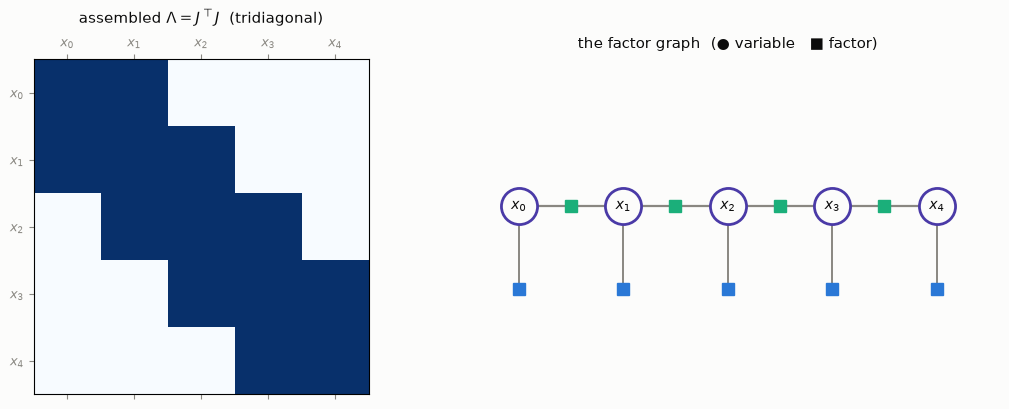

each between-factor -> one off-diagonal;  each prior -> one diagonal bump


In [7]:
# picture: the assembled Lambda (left) and the graph whose adjacency it is (right)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), facecolor="#fcfcfb")

ax[0].matshow(np.abs(Lam) > 1e-9, cmap="Blues", vmin=0, vmax=1)
ax[0].set_title(r"assembled $\Lambda = J^\top J$  (tridiagonal)", color=INK, fontsize=11, pad=10)
ax[0].set_xticks(range(K)); ax[0].set_yticks(range(K))
ax[0].set_xticklabels([f"$x_{k}$" for k in range(K)])
ax[0].set_yticklabels([f"$x_{k}$" for k in range(K)])
ax[0].tick_params(colors=MUTED, labelsize=9)

axg = ax[1]
pos = {k: (k, 0.0) for k in range(K)}
for k in range(K - 1):                                  # between-factors: edges + squares
    axg.plot([k, k + 1], [0, 0], color=MUTED, lw=1.6, zorder=1)
    axg.plot(k + 0.5, 0, "s", ms=9, color=AQUA, zorder=2)
for k in range(K):                                      # priors: a small square below
    axg.plot([k, k], [0, -0.4], color=MUTED, lw=1.4, zorder=1)
    axg.plot(k, -0.4, "s", ms=9, color=BLUE, zorder=2)
    axg.plot(k, 0, "o", ms=26, color="#fcfcfb", markeredgecolor=VIOLET, mew=2, zorder=3)
    axg.text(k, 0, f"$x_{k}$", ha="center", va="center", color=INK, fontsize=10, zorder=4)
axg.set_title("the factor graph  (● variable   ■ factor)", color=INK, fontsize=11, pad=8)
axg.set_xlim(-0.6, K - 0.4); axg.set_ylim(-0.9, 0.7); axg.axis("off")
fig.tight_layout(); plt.show()

print("each between-factor -> one off-diagonal;  each prior -> one diagonal bump")

### Reading the numbers

The **pattern** is structural, but the **magnitudes** are real precisions — worth reading off, because everything the solver later does is a tug-of-war between them. Two factor types feed this $\Lambda$:

- a weak **prior** on every node, $\sigma=3$ → precision $1/\sigma^2 = 1/9 \approx 0.111$;
- **odometry** between neighbours, $\sigma=1$ → precision $1/1 = 1$.

**Diagonal $\Lambda_{ii}$ = total certainty on pose $i$ = the sum of the precisions of every factor touching it.** That's why the ends differ from the middle:

- **endpoints** $x_0, x_4$ have one prior + one odometry link → $1/9 + 1 = 1.111$;
- **interior** $x_1, x_2, x_3$ have one prior + *two* odometry links → $1/9 + 1 + 1 = 2.111$.

An endpoint is genuinely *less constrained* — only one neighbour holds it — and the matrix says so with a smaller diagonal. (Invert $\Lambda$ and that shows up as larger posterior variance at the ends: the classic "the middle of a chain is pinned down better than the tips.")

**Off-diagonal $\Lambda_{ij}=-1$ = the coupling from the between-factor joining $i$ and $j$.** It is *negative* because a between-factor says $x_j-x_i\approx d$, whose cross-term is $-1$; its magnitude is how tightly the two poses are yoked. That coupling is exactly what makes neighbours **correlated** in the posterior — move one and its neighbour wants to follow.

So the split is deliberate: priors weak ($\sigma=3$), odometry strong ($\sigma=1$), so the graph trusts *relative motion* far more than the *absolute anchors*. Flip that ratio — tighten the priors, loosen odometry — and the diagonals grow, the coupling weakens, and the solve would lean on absolute positions instead. The numbers here **are** those modelling choices, written as certainties.

## 5 · The batch solve — and M0, reproduced

The solver is now three lines: build a `residual_fn` that unpacks $x$ into `values`, linearises the graph, and returns $(r,J)$ — then hand it to M1's `gauss_newton` (or `levenberg_marquardt`). The graph *is* the batch optimiser.

In [8]:
from factorgraph import gauss_newton, levenberg_marquardt

def solve(graph, values, method="gn", **kw):
    """Solve a factor graph from an initial `values` dict. Returns (estimate, NLSResult)."""
    dims = {k: np.atleast_1d(v).size for k, v in values.items()}
    ordering = Ordering(dims)
    def residual_fn(x):
        return graph.linearize(ordering.unpack(x), ordering)
    solver = gauss_newton if method == "gn" else levenberg_marquardt
    result = solver(residual_fn, ordering.pack(values), **kw)
    return ordering.unpack(result.x), result

# attach as a method so we can call graph.solve(...)
FactorGraph.solve = lambda self, values, **kw: solve(self, values, **kw)

### Example A — a Kalman update is a two-factor graph

Back to M0. We have a scalar state $x$ with a **prior** $\mathcal N(\bar\mu,\bar\sigma^2)$ and a direct **measurement** $z$ with noise $\sigma_z$. That is two factors: a `PriorFactor` for the prior and — since the measurement observes $x$ directly ($H=I$) — another `PriorFactor` at $z$. Solve, and compare against the closed-form Kalman / information fusion $\Lambda=\bar\sigma^{-2}+\sigma_z^{-2}$, $\mu=\Lambda^{-1}(\bar\mu/\bar\sigma^{2}+z/\sigma_z^{2})$.

In [19]:
mu_bar, sig_bar = 2.0, 1.5        # prior belief
z,      sig_z   = 5.0, 0.8        # a direct measurement of x

gA = FactorGraph()
gA.add(PriorFactor("x", mean=[mu_bar], sigma=sig_bar))
gA.add(PriorFactor("x", mean=[z],      sigma=sig_z))     # H = I  ->  a prior at z
est, res = gA.solve({"x": np.array([0.0])})

Lam_cf = 1 / sig_bar**2 + 1 / sig_z**2
mu_cf  = (mu_bar / sig_bar**2 + z / sig_z**2) / Lam_cf
print(f"engine posterior mean : {est['x'][0]:.6f}")
print(f"closed-form Kalman     : {mu_cf:.6f}")
assert abs(est["x"][0] - mu_cf) < 1e-6

Lam_A, _ = gA.information(est, Ordering({"x": 1}))
print(f"engine   Lambda        : {Lam_A[0,0]:.6f}")
print(f"1/sig_bar^2 + 1/sig_z^2: {Lam_cf:.6f}   (the two factors ADD, exactly as in M2)")
assert abs(Lam_A[0, 0] - Lam_cf) < 1e-9
print(f"\nsolved in {res.iterations} iterations, cost {res.cost_history[0]:.4f} -> {res.cost:.4f}")

engine posterior mean : 4.335640
closed-form Kalman     : 4.335640
engine   Lambda        : 2.006944
1/sig_bar^2 + 1/sig_z^2: 2.006944   (the two factors ADD, exactly as in M2)

solved in 2 iterations, cost 20.4201 -> 1.5571


There it is: the engine reproduces M0's posterior to machine precision, and the assembled $\Lambda$ is the **sum** of the two factors' precisions — M2's "fusion is addition." Both factors are linear, so the **first** Gauss–Newton step already lands on the exact minimum; the solver runs one more only to confirm the cost stopped changing (hence `iterations` reads 2, not 1). A linear graph is a one-shot solve — that is why M0's Kalman update needed a single step. Nonlinearity is the only thing that forces real iteration, and we meet it in §6.2.

## 6 · 2D localisation: a GPS + odometry chain

Now a real graph. A robot drives a path of 8 positions $p_0,\dots,p_7\in\mathbb R^2$ (still Euclidean — heading and rotation wait for M4). Two sensors:

- **odometry** — a noisy estimate of each step $p_k-p_{k-1}$ → a `BetweenFactor` per step;
- **GPS** — an occasional noisy absolute fix → a `PriorFactor` on that pose.

Odometry alone **drifts**: integrate the noisy steps from the first fix and the error grows without bound (dead reckoning). GPS alone is jumpy. The graph fuses them — every factor pulling at once — into a trajectory better than either. We initialise from dead reckoning and let the solver clean it up.

> **Where does the data come from — and why odometry appears "twice."** Keep three things apart: the **variables** are the poses $p_0,\dots,p_7$ (the only unknowns); the **measurements** are the odometry steps and GPS fixes (data the sensors give us); the **factors** are constraints *built from* those measurements. Odometry is a measurement, never a variable — it just gets used in two roles: (1) as a `BetweenFactor` (a constraint in the cost: "$p_k-p_{k-1}$ should match this step"), and (2) to build the **initial guess** by chaining the steps (dead reckoning). Role 2 only *seeds* the solver — it adds no information and, since this graph is linear, the answer is identical from any starting point. This is exactly how real robots do it: wheel encoders → a relative step → a between-factor, and dead-reckoned odometry as the initial guess. The only thing *synthetic* here is that we invent a ground-truth path and fabricate readings from it (`odom = true step + noise`, `gps = true position + noise`) **so we can score the result** (ATE); a real run just swaps those two lines for logged sensor data and every factor and the solve stay the same.

In [10]:
rng = np.random.default_rng(0)
K = 8
true = np.zeros((K, 2))                       # ground-truth path (unknown to the solver)
step = np.array([1.0, 0.4])
for k in range(1, K):
    true[k] = true[k - 1] + step + np.array([0.0, 0.15 * np.sin(k)])

odom_sigma, gps_sigma = 0.05, 0.5
odom = np.array([true[k] - true[k - 1] + odom_sigma * rng.standard_normal(2)
                 for k in range(1, K)])       # noisy step measurements
gps_idx = [0, 3, 7]                           # GPS only fixes a few poses
gps = {k: true[k] + gps_sigma * rng.standard_normal(2) for k in gps_idx}

graph = FactorGraph()
for k in gps_idx:
    graph.add(PriorFactor(k, mean=gps[k], sigma=gps_sigma))
for k in range(1, K):
    graph.add(BetweenFactor(k - 1, k, measured=odom[k - 1], sigma=odom_sigma))
print(f"{len(graph.factors)} factors  ({len(gps_idx)} GPS priors + {K-1} odometry betweens)"
      f"  over {K} pose variables")

# dead reckoning: integrate odometry from the first GPS fix -> the initial guess
dr = np.zeros((K, 2)); dr[0] = gps[0]
for k in range(1, K):
    dr[k] = dr[k - 1] + odom[k - 1]

est, res = graph.solve({k: dr[k].copy() for k in range(K)})
fused = np.array([est[k] for k in range(K)])

ate = lambda P: np.sqrt(((P - true) ** 2).sum(1)).mean()
print(f"\nGauss-Newton: {res.iterations} iterations, converged={res.converged}")
print(f"cost history: {np.round(res.cost_history, 4)}")
print(f"mean error  dead-reckoning: {ate(dr):.4f}   fused: {ate(fused):.4f}")
assert ate(fused) < ate(dr)
assert abs(res.cost_history[1] - res.cost_history[-1]) < 1e-9   # linear -> 1st step is exact

10 factors  (3 GPS priors + 7 odometry betweens)  over 8 pose variables

Gauss-Newton: 2 iterations, converged=True
cost history: [3.6543 1.7248 1.7248]
mean error  dead-reckoning: 0.7100   fused: 0.1901


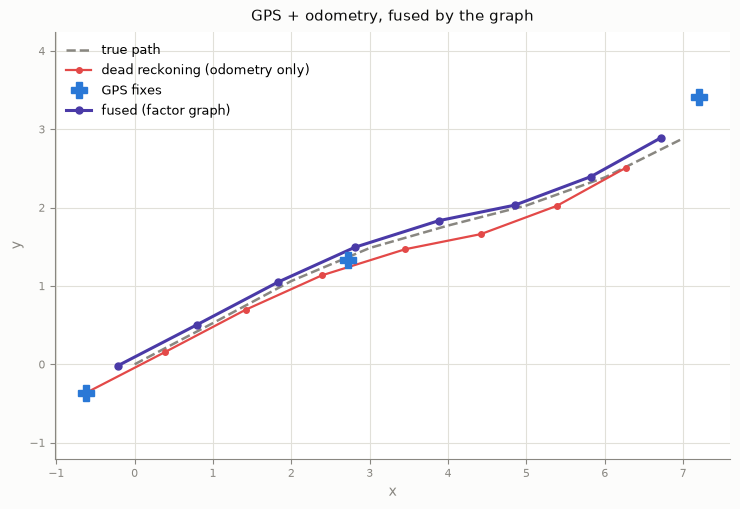

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor="#fcfcfb")
ax.plot(true[:, 0], true[:, 1], "--", color=MUTED, lw=1.8, label="true path", zorder=1)
ax.plot(dr[:, 0], dr[:, 1], "-o", color=RED, ms=4, lw=1.6, label="dead reckoning (odometry only)", zorder=2)
gx = np.array([gps[k] for k in gps_idx])
ax.plot(gx[:, 0], gx[:, 1], "P", color=BLUE, ms=12, label="GPS fixes", zorder=4)
ax.plot(fused[:, 0], fused[:, 1], "-o", color=VIOLET, ms=5, lw=2.2, label="fused (factor graph)", zorder=3)
_style(ax, "GPS + odometry, fused by the graph")
ax.set_xlabel("x", color=MUTED); ax.set_ylabel("y", color=MUTED)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_aspect("equal", "datalim")
fig.tight_layout(); plt.show()

The fused path (violet) tracks the truth: the GPS priors pin it down where they exist, the odometry between-factors keep the shape rigid in between, and the whole thing settles in a **single** Gauss–Newton step because every factor here is linear. This is nothing but a **batch Kalman update over the entire trajectory at once** — M0's two-factor solve, scaled to $8$ variables and $10$ factors. And its information matrix is the M2 chain, for real:

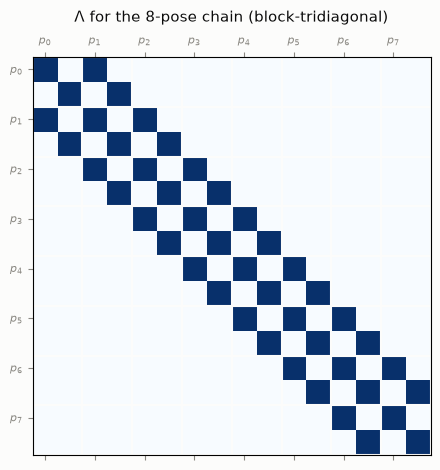

far-apart poses share no factor -> zero block: True


In [12]:
ordering2 = Ordering({k: 2 for k in range(K)})
Lam2, _ = graph.information(est, ordering2)

fig, ax = plt.subplots(figsize=(4.8, 4.8), facecolor="#fcfcfb")
ax.matshow(np.abs(Lam2) > 1e-9, cmap="Blues", vmin=0, vmax=1)
ax.set_title(r"$\Lambda$ for the 8-pose chain (block-tridiagonal)", color=INK, fontsize=11, pad=10)
for t in range(0, 2 * K + 1, 2):                         # 2x2 block gridlines
    ax.axhline(t - 0.5, color="#fcfcfb", lw=1.5); ax.axvline(t - 0.5, color="#fcfcfb", lw=1.5)
ax.set_xticks(range(0, 2 * K, 2)); ax.set_yticks(range(0, 2 * K, 2))
ax.set_xticklabels([f"$p_{k}$" for k in range(K)]); ax.set_yticklabels([f"$p_{k}$" for k in range(K)])
ax.tick_params(colors=MUTED, labelsize=8)
fig.tight_layout(); plt.show()

print("far-apart poses share no factor -> zero block:", np.abs(Lam2[0:2, 8:10]).max() < 1e-9)

> **Why it looks checkered, not solid.** Each pose is 2D, so this is a 16×16 matrix in 2×2 blocks — but the nonzero blocks come out **diagonal**, not full, giving a checkerboard. That's because every factor here has diagonal noise and a $\pm I$ Jacobian, so a pose's $x$ never couples to its $y$: $\Lambda$ is really **two independent 1D tridiagonal chains — one for $x$, one for $y$ — interleaved** (read the even rows/cols alone and you get exactly the §4 1D matrix). The title still holds at the *block* level (the nonzero **blocks** form a tridiagonal band; far-apart poses give a zero block), it's just that each block happens to be diagonal. The blocks fill in solid once **M4** puts poses on SE(2)/SE(3) and rotation couples $x$, $y$, and $\theta$ — or if a sensor had correlated (non-diagonal) noise.

### 6.2 · Adding a nonlinear factor — now Gauss–Newton earns its name

Everything so far was linear, so the solver was a one-shot. Add a **range** sensor — the robot measures its distance to a beacon at a known location from a few poses — and the picture changes. $\lVert p_k-\ell\rVert$ is nonlinear in $p_k$, so its Jacobian depends on where we currently think $p_k$ is. Gauss–Newton must **re-linearise and step, repeatedly**, until it settles.

In [13]:
beacon = np.array([4.0, -3.0])
graph_nl = FactorGraph()
for k in gps_idx:
    graph_nl.add(PriorFactor(k, mean=gps[k], sigma=gps_sigma))
for k in range(1, K):
    graph_nl.add(BetweenFactor(k - 1, k, measured=odom[k - 1], sigma=odom_sigma))
for k in [2, 4, 6]:                                       # range from three poses
    meas = np.linalg.norm(true[k] - beacon) + 0.1 * rng.standard_normal()
    graph_nl.add(RangeFactor(k, beacon, meas, sigma=0.3))

est_nl, res_nl = graph_nl.solve({k: dr[k].copy() for k in range(K)})
print(f"linear graph   : {res.iterations} GN iterations")
print(f"with range fac.: {res_nl.iterations} GN iterations, converged={res_nl.converged}")
print(f"cost history   : {np.round(res_nl.cost_history, 4)}")
assert res_nl.iterations > 2                              # genuinely nonlinear now

linear graph   : 2 GN iterations
with range fac.: 4 GN iterations, converged=True
cost history   : [5.7847 1.7927 1.7856 1.7856 1.7856]


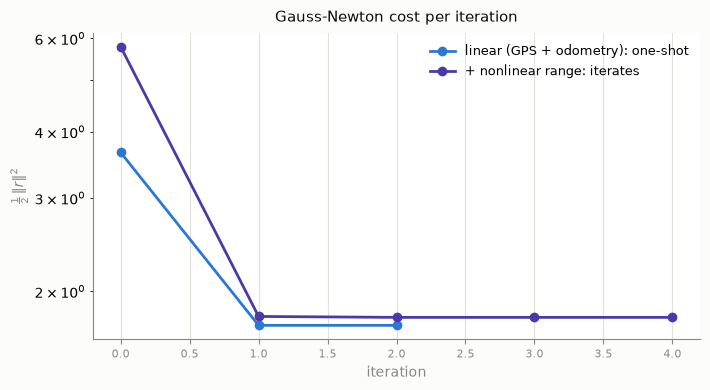

nonlinearity is exactly what forces iteration -- and M4 makes even the
between-factors nonlinear by putting poses on SE(2)/SE(3) instead of R^2.


In [14]:
fig, ax = plt.subplots(figsize=(7.2, 4.0), facecolor="#fcfcfb")
ax.semilogy(range(len(res.cost_history)), res.cost_history, "-o", color=BLUE, lw=2,
            label="linear (GPS + odometry): one-shot")
ax.semilogy(range(len(res_nl.cost_history)), res_nl.cost_history, "-o", color=VIOLET, lw=2,
            label="+ nonlinear range: iterates")
_style(ax, "Gauss-Newton cost per iteration")
ax.set_xlabel("iteration", color=MUTED); ax.set_ylabel(r"$\frac{1}{2}\,\Vert r\Vert^2$", color=MUTED)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

print("nonlinearity is exactly what forces iteration -- and M4 makes even the")
print("between-factors nonlinear by putting poses on SE(2)/SE(3) instead of R^2.")

## 7 · Tie-back and takeaways

- A **factor graph** is variables + factors. Each **factor** contributes a whitened local  residual and Jacobian; the **graph** stacks them into $(r,J)$ and the M1 solver minimises  $\tfrac12\lVert r\rVert^2$. That object is a **batch optimiser**.
- **Assembly is the sparse $\Lambda$ of M2**: each factor writes only into the blocks of the  variables it touches, so $\Lambda=J^\top J$ inherits the graph's adjacency. A pose chain  gives a (block-)tridiagonal $\Lambda$ — the matrix we drew by hand in M2, now assembled.
- **Linear factors solve in one step** (a batch Kalman update — M0 at scale); **nonlinear  factors force Gauss–Newton to iterate** (M1's machinery, finally exercised on a graph).
- We reproduced M0 exactly and localised in 1D and 2D with the *same* engine — only the  factors changed.

**Where this leads.** M4 replaces $\mathbb R^2$ poses with **SE(2)/SE(3)**: retraction and manifold Jacobians make even a between-factor nonlinear (and fix the heading-wraparound hacks Euclidean code needs). M5 makes the solve **incremental** — eliminate variables in a good order, reuse the factorisation, and pay for the fill-in M2 warned about. M6 maps every object here onto **GTSAM** one-to-one: `FactorGraph` $\to$ `NonlinearFactorGraph`, `values` $\to$ `Values`, our `PriorFactor`/`BetweenFactor` $\to$ theirs. From here on, every estimator we build is a factor graph.

## Appendix A · Whitening in full

For a general (non-diagonal) covariance $\Sigma$ we need any $W$ with $W^\top W=\Sigma^{-1}$. The standard choice is the Cholesky factor: if $\Sigma^{-1}=LL^\top$ then $W=L^\top$ works, since $W^\top W=LL^\top=\Sigma^{-1}$. Whitening then *rotates and scales* the residual so that its components are unit-variance and uncorrelated — turning the tilted Mahalanobis ellipse into a plain circle, which is why $\lVert Wr\rVert^2$ is the right cost. For a diagonal $\Sigma=\operatorname{diag}(\sigma_i^2)$ this collapses to $W=\operatorname{diag}(1/\sigma_i)$, the `_W` we used. Extending `_W` to full $\Sigma$ is one line — `np.linalg.cholesky(inv(Sigma)).T` — and every factor keeps working unchanged, because they only ever multiply by `self.W`.

## Appendix B · Two ways to assemble

We built a tall $J$ and let the solver form $\Lambda=J^\top J$ implicitly (M1 solves the least-squares problem on $J$ directly). The information-form alternative accumulates $\Lambda$ **without ever stacking $J$**: initialise $\Lambda=0,\ \eta=0$ and, for each factor, add $J_f^\top J_f$ into its variables' blocks and $-J_f^\top r_f$ into their segments of $\eta$. This is literally M0's "each factor adds a block" and M2's additive $\Lambda=\sum_i\Lambda_i$. The two give the same normal equations; real solvers pick per problem — accumulate a sparse $\Lambda$ and factorise it (Cholesky) when it is very sparse, or keep $J$ and use QR when conditioning matters (Appendix C).

## Appendix C · Why solve on $J$, not on $\Lambda$

Forming $\Lambda=J^\top J$ **squares the condition number**: $\kappa(\Lambda)=\kappa(J)^2$ (the same fact behind M1's Appendix D). A problem that is merely stiff in $J$ becomes numerically nasty in $\Lambda$. So although $\Lambda$ is the right object to *think* in (M2) and to reason about sparsity with, a careful solver factorises $J$ itself (QR), or $\Lambda$ via Cholesky only when it is well-conditioned and very sparse. Our `gauss_newton` takes the safe route — `np.linalg.lstsq` on $J$ — which is why the examples above are stable even without any special ordering.

## Appendix D · Ordering and fill-in

The **order** in which variables occupy $x$ (our `Ordering`) does not change the answer, but it changes how expensive the solve is. Factorising $\Lambda$ eliminates variables one by one, and eliminating a variable **fills in** edges among its neighbours — exactly the Schur complement / fill-in of M2 §5. A bad order (eliminate a hub first) densifies $\Lambda$; a good order (e.g. along the chain) keeps it sparse. For our small dense solves it is moot, but at scale a good elimination order is the difference between real-time and hopeless — which is the machinery M5 builds.

## Appendix E · What *bipartite* means

A graph is a set of **vertices** with **edges** joining them. A graph is **bipartite** when its vertices split into two disjoint groups and **every edge goes *between* the groups, never *within* one**. The classic mental image is a dance floor with leads on one side and follows on the other: partnerships only ever cross the aisle — no lead pairs with a lead.

A factor graph is bipartite with the two groups being:

- **variables** (circles) — the unknowns, and
- **factors** (squares) — the pieces of information.

Every edge runs **factor → variable**: an edge means "this factor constrains that variable." There is never a variable–variable edge, nor a factor–factor edge. That is not a stylistic choice — it is what the objects *are*. A factor is a residual $r_f$ that reads some variables and returns a number; drawing an edge to each variable it reads is just recording which ones. Two variables are never wired directly, because in this model nothing relates two unknowns *except through a shared measurement*.

This is exactly why §4's assembly is so mechanical. Each factor's row-block in $J$ has nonzeros **only** in the columns of the variables on its edges; everything else is zero. And two variables end up coupled in $\Lambda=J^\top J$ (a nonzero off-diagonal block) **precisely when some factor touches both** — a two-hop path variable → factor → variable across the aisle. "Which variables share a factor" *is* "which cells of $\Lambda$ are nonzero," which *is* the sparsity M2 drew by hand. The bipartite structure is the reason the graph, the matrix, and the code all line up.